# 04 (Bônus) — Explicabilidade com SHAP e Ablation Study

**Objetivo:** Aplicar técnicas de XAI (Explainable AI) ao melhor classificador para entender quais features manuais mais influenciam as decisões do modelo.

**Conteúdo:**
1. SHAP `summary_plot` (importância global)
2. SHAP `beeswarm_plot` (efeito de cada feature)
3. Permutation Importance como verificação cruzada
4. **Ablation Study:** treinar com grupos de features isolados e comparar F1

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP disponível.')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP não instalado. Execute: pip install shap')

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUTS_DIR = Path('../outputs')
print('Imports carregados.')

SHAP disponível.
Imports carregados.


## 1. Carregamento e preparação dos dados

In [2]:
X = pd.read_csv(OUTPUTS_DIR / 'X.csv')
y = pd.read_csv(OUTPUTS_DIR / 'y.csv').squeeze()

with open(OUTPUTS_DIR / 'pipeline_config.json') as f:
    CONFIG = json.load(f)
FINAL_CLASSES = {int(k): v for k, v in CONFIG['final_classes'].items()}
label_names = [FINAL_CLASSES[i] for i in sorted(FINAL_CLASSES.keys())]

# Splits
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=RANDOM_STATE)

# Normalização
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Dados carregados: {X.shape[0]} amostras, {X.shape[1]} features.')
print(f'Treino: {X_train.shape[0]} | Val: {X_val.shape[0]} | Teste: {X_test.shape[0]}')

Dados carregados: 1958 amostras, 31 features.
Treino: 1370 | Val: 294 | Teste: 294


In [3]:
# ── Treina Random Forest com os melhores hiperparâmetros (reutilizado) ────────
# (Em produção, carregaríamos o modelo salvo; aqui re-treinamos para simplicidade)
best_rf = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_split=2, max_features='sqrt',
    random_state=RANDOM_STATE, n_jobs=-1
)
best_rf.fit(X_train_s, y_train)

test_f1 = f1_score(y_test, best_rf.predict(X_test_s), average='macro')
print(f'RF re-treinado | F1-macro (teste): {test_f1:.4f}')

RF re-treinado | F1-macro (teste): 0.8866


## 2. SHAP — Explicabilidade Global

In [9]:
if SHAP_AVAILABLE:
    print('Calculando SHAP values (TreeExplainer)...')
    # Usa amostra para velocidade
    n_background = min(200, X_train_s.shape[0])
    bg_idx = np.random.choice(X_train_s.shape[0], n_background, replace=False)
    X_bg = pd.DataFrame(X_train_s[bg_idx], columns=X.columns)
    X_explain = pd.DataFrame(X_test_s, columns=X.columns)

    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_explain)
    
    # Para multiclasse: shap_values tem shape (n_samples, n_features, n_classes)
    # Queremos importância por feature (média sobre amostras e classes)
    shap_abs = np.abs(shap_values)
    
    if shap_abs.ndim == 3:
        # (n_samples, n_features, n_classes) → média sobre samples (axis 0) e classes (axis 2)
        shap_importance_vals = shap_abs.mean(axis=(0, 2))
    elif shap_abs.ndim == 2:
        # (n_samples, n_features) - caso binário
        shap_importance_vals = shap_abs.mean(axis=0)
    else:
        # Caso genérico: redimensiona para (n_samples, n_features) e faz média
        shap_importance_vals = shap_abs.reshape(shap_abs.shape[0], -1).mean(axis=0)
    
    shap_importance = pd.Series(shap_importance_vals, index=X.columns).sort_values(ascending=False)
    print('SHAP calculado.')

Calculando SHAP values (TreeExplainer)...
SHAP calculado.


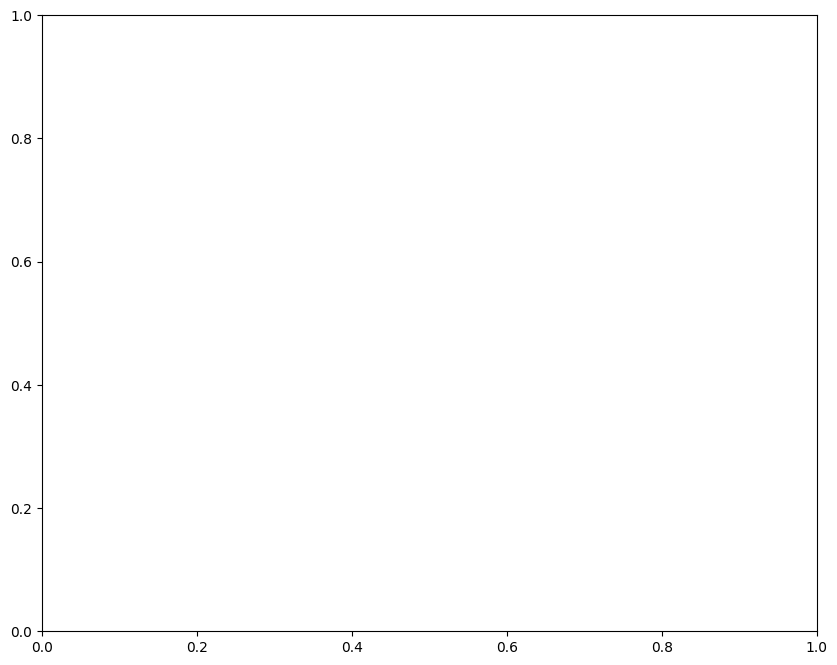

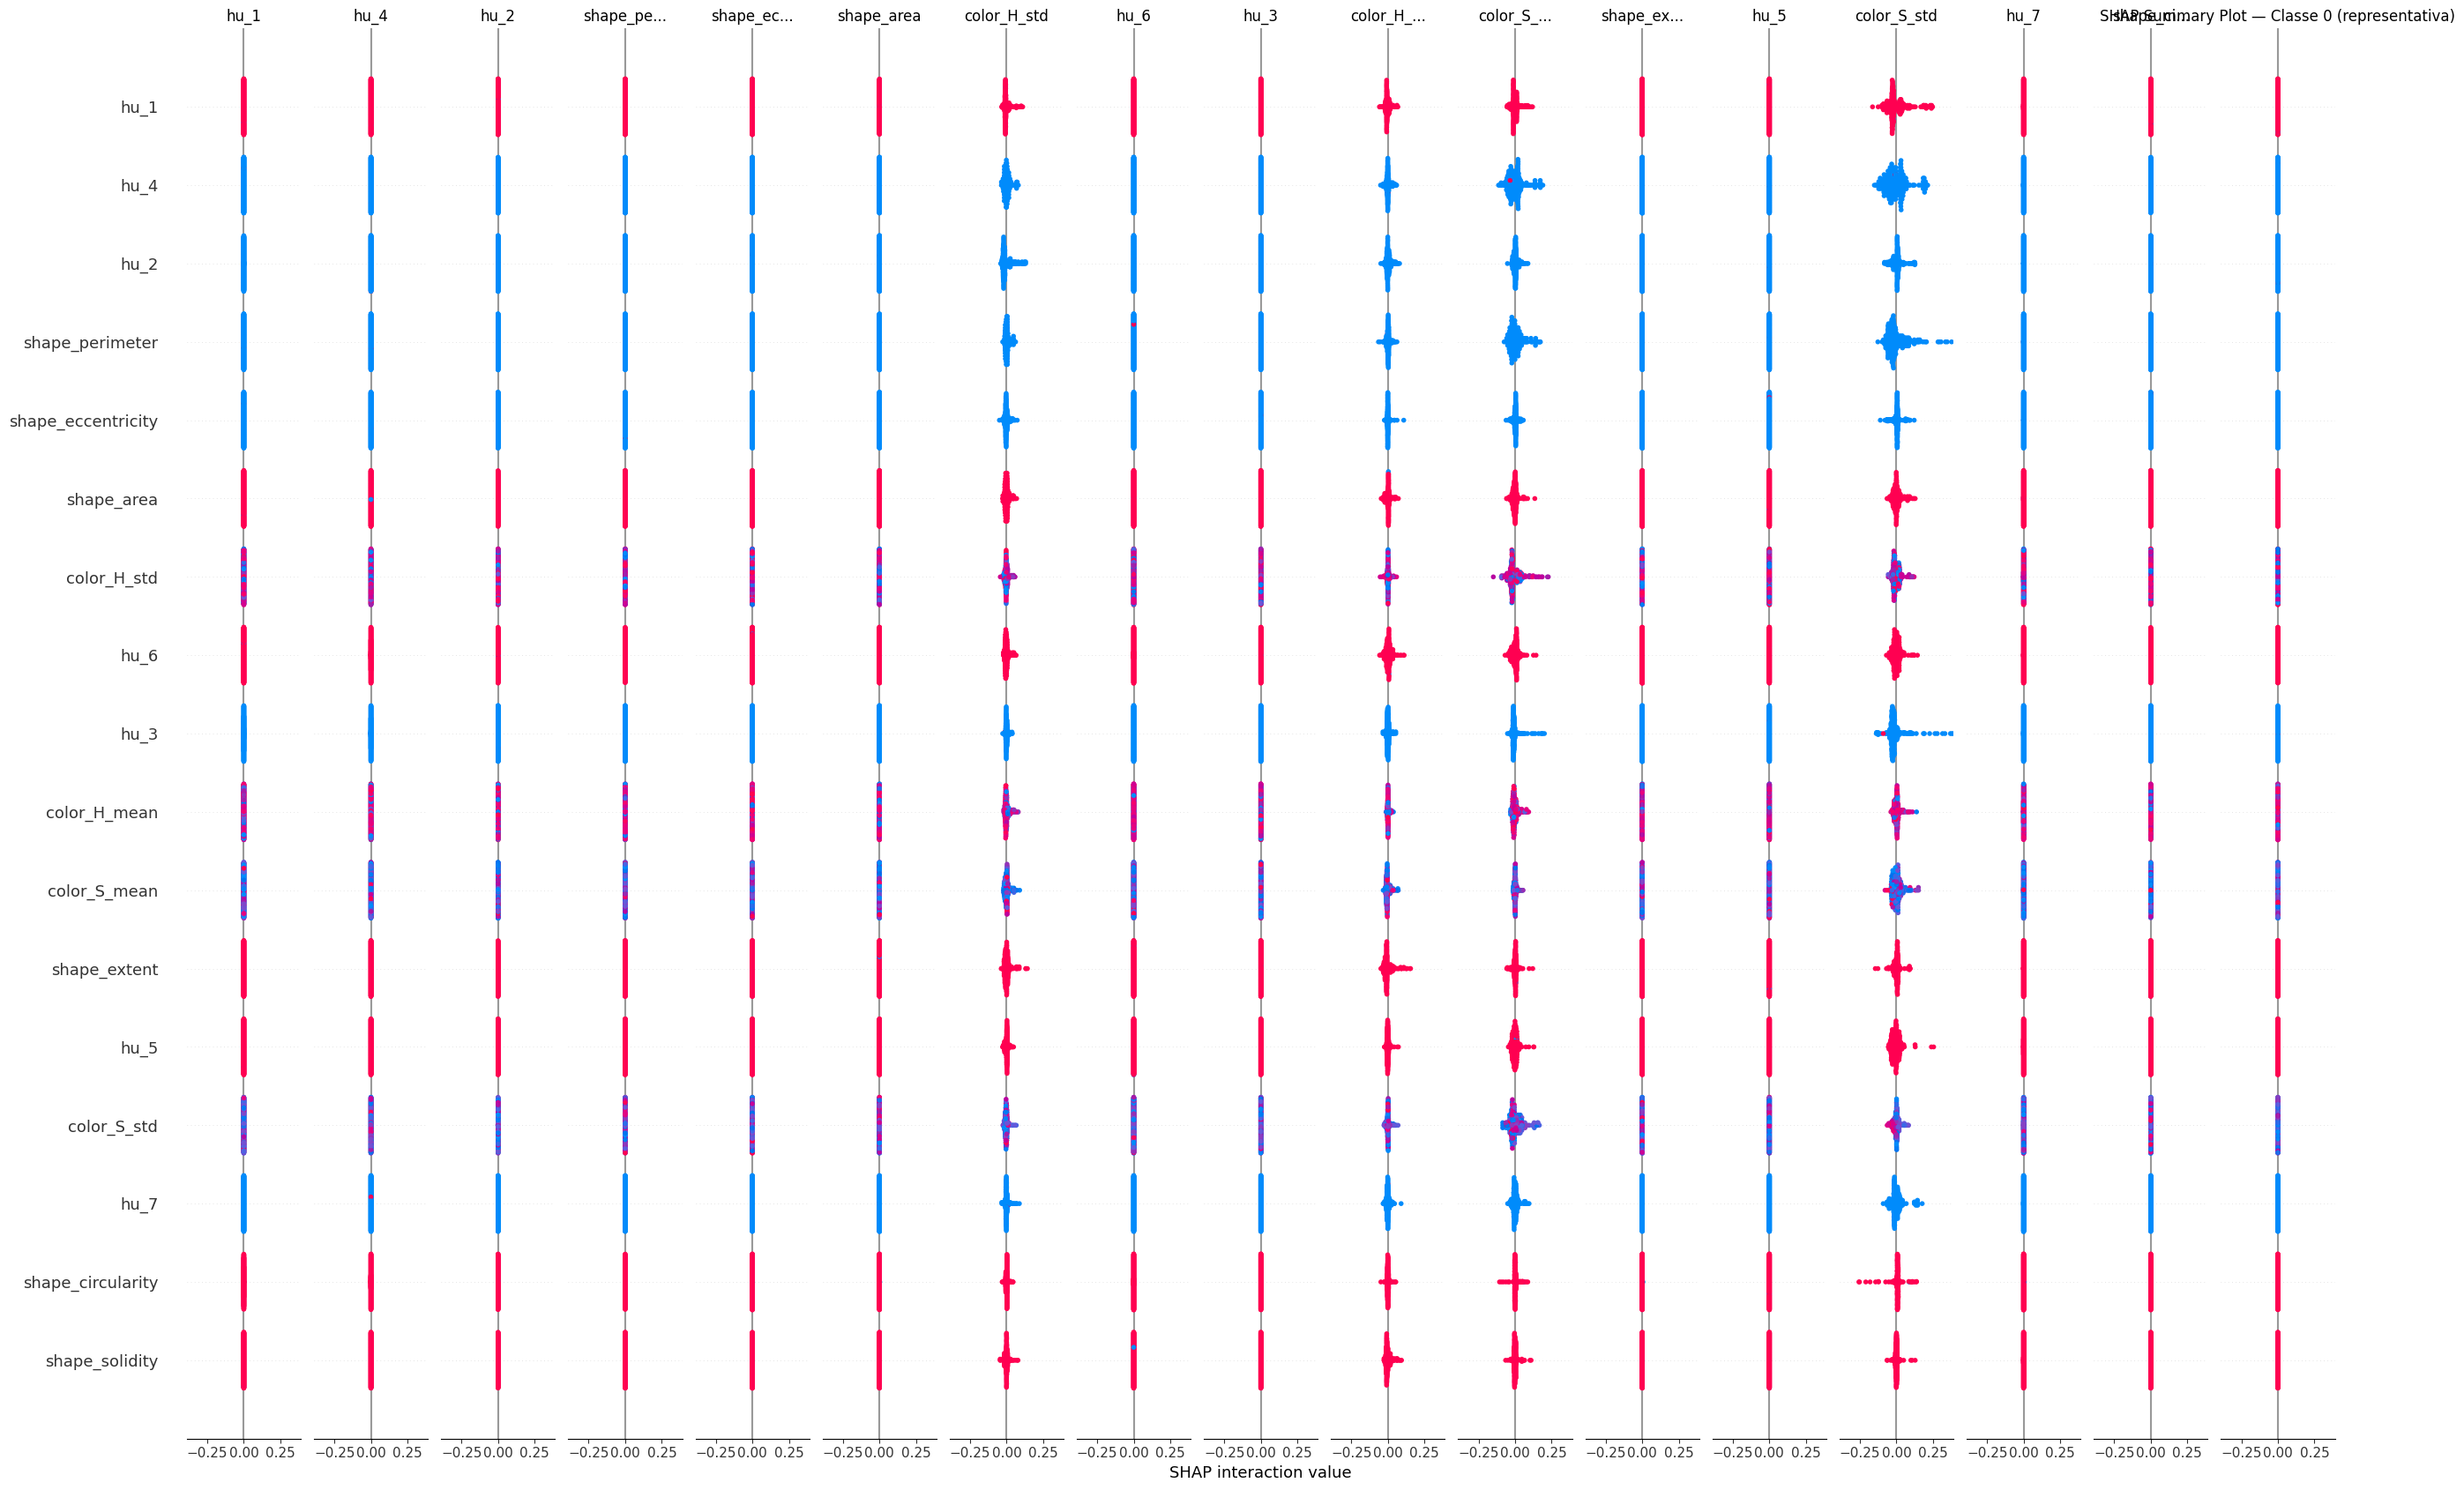

SHAP summary plot salvo.


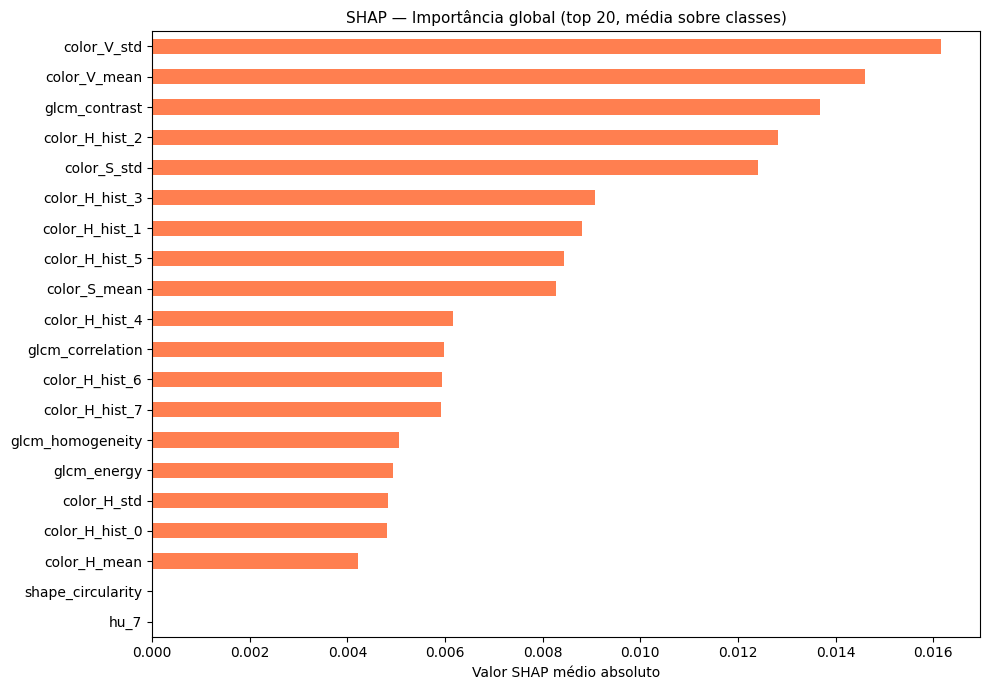

Top 10 features por SHAP:
color_V_std       0.016149
color_V_mean      0.014603
glcm_contrast     0.013671
color_H_hist_2    0.012828
color_S_std       0.012403
color_H_hist_3    0.009063
color_H_hist_1    0.008812
color_H_hist_5    0.008435
color_S_mean      0.008281
color_H_hist_4    0.006166


In [10]:
if SHAP_AVAILABLE:
    # Summary plot (beeswarm) — usa a primeira classe como representativo
    fig, ax = plt.subplots(figsize=(10, 8))

    sv = shap_values[0] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_explain, show=False, max_display=20, plot_size=None)
    plt.title('SHAP Summary Plot — Classe 0 (representativa)', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP summary plot salvo.')

    # Bar plot de importância global
    fig, ax = plt.subplots(figsize=(10, 7))
    shap_importance.head(20)[::-1].plot(kind='barh', ax=ax, color='coral')
    ax.set_title('SHAP — Importância global (top 20, média sobre classes)', fontsize=11)
    ax.set_xlabel('Valor SHAP médio absoluto')
    plt.tight_layout()
    fig.savefig(OUTPUTS_DIR / 'shap_importance_bar.png', dpi=150)
    plt.show()

    print('Top 10 features por SHAP:')
    print(shap_importance.head(10).to_string())
else:
    print('SHAP não disponível. Instale com: pip install shap')

## 3. Permutation Importance (verificação cruzada do SHAP)

Calculando permutation importance no conjunto de teste...
Top 15 features por Permutation Importance:


,feature,importance,std
0,color_V_std,0.046681,0.010944
1,color_V_mean,0.043685,0.009013
2,color_S_std,0.026695,0.005977
3,glcm_contrast,0.014100,0.004518
4,color_H_hist_2,0.003792,0.005481
5,color_H_hist_6,0.001901,0.004719
6,color_H_hist_0,0.000749,0.002293
7,color_H_std,0.000469,0.003881
8,hu_1,0.000000,0.000000
9,shape_perimeter,0.000000,0.000000


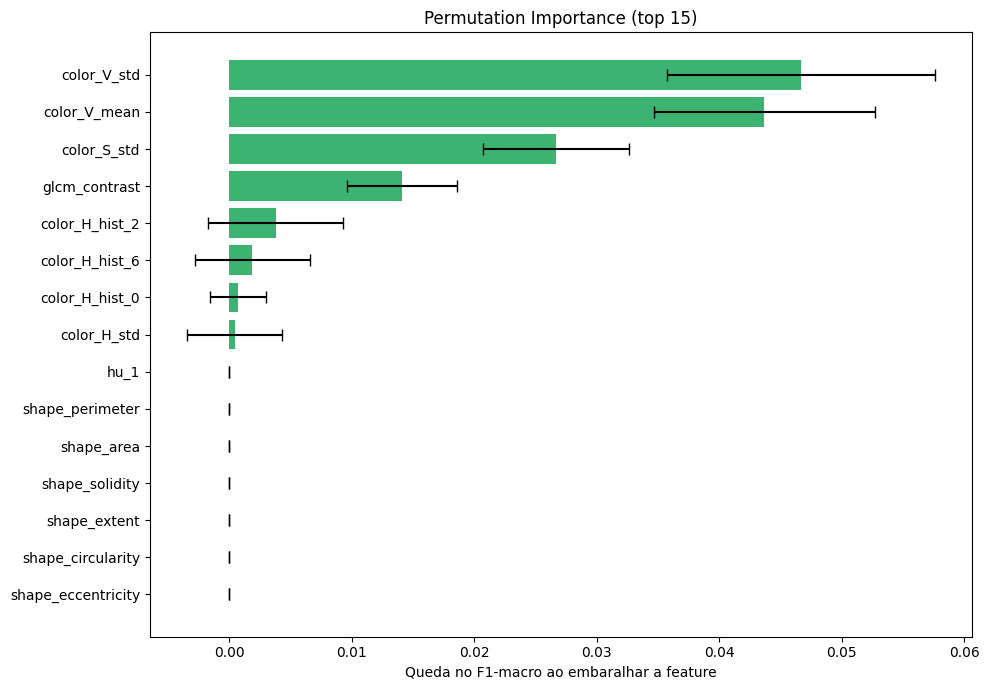

Figura salva: outputs/permutation_importance.png


In [11]:
print('Calculando permutation importance no conjunto de teste...')
perm_result = permutation_importance(
    best_rf, X_test_s, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='f1_macro', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':     X.columns,
    'importance':  perm_result.importances_mean,
    'std':         perm_result.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 features por Permutation Importance:')
display(perm_df.head(15))

fig, ax = plt.subplots(figsize=(10, 7))
top15 = perm_df.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1],
        xerr=top15['std'][::-1], color='mediumseagreen', capsize=4)
ax.set_title('Permutation Importance (top 15)', fontsize=12)
ax.set_xlabel('Queda no F1-macro ao embaralhar a feature')
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'permutation_importance.png', dpi=150)
plt.show()
print('Figura salva: outputs/permutation_importance.png')

## 4. Ablation Study — Grupos de Features

Treinamos o modelo com cada grupo de features isolado (apenas forma, apenas cor, apenas textura, apenas momentos Hu) e comparamos o F1-macro no conjunto de teste.

Isso revela qual grupo de features carrega mais informação discriminante.

In [12]:
# Define grupos de features
feature_groups = {
    'Apenas Forma':     [f for f in X.columns if f.startswith('shape_')],
    'Apenas Hu':        [f for f in X.columns if f.startswith('hu_')],
    'Apenas Cor (HSV)': [f for f in X.columns if f.startswith('color_')],
    'Apenas Textura':   [f for f in X.columns if f.startswith('glcm_')],
    'Forma + Cor':      [f for f in X.columns if f.startswith('shape_') or f.startswith('color_')],
    'Cor + Textura':    [f for f in X.columns if f.startswith('color_') or f.startswith('glcm_')],
    'Todas (baseline)': list(X.columns)
}

for k, v in feature_groups.items():
    print(f'{k:30s}: {len(v)} features')

Apenas Forma                  : 6 features
Apenas Hu                     : 7 features
Apenas Cor (HSV)              : 14 features
Apenas Textura                : 4 features
Forma + Cor                   : 20 features
Cor + Textura                 : 18 features
Todas (baseline)              : 31 features


In [13]:
ablation_results = []

for group_name, feats in feature_groups.items():
    if not feats:
        continue

    # Sub-seleciona as features do grupo
    Xg_train = X_train[feats]
    Xg_test  = X_test[feats]

    # Normalização independente
    sc_g = StandardScaler()
    Xg_train_s = sc_g.fit_transform(Xg_train)
    Xg_test_s  = sc_g.transform(Xg_test)

    # Treina RF com os hiperparâmetros base
    rf_g = RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf_g.fit(Xg_train_s, y_train)

    # F1 no teste
    y_pred_g = rf_g.predict(Xg_test_s)
    f1_g     = f1_score(y_test, y_pred_g, average='macro', zero_division=0)
    acc_g    = (y_pred_g == y_test.values).mean()

    ablation_results.append({
        'Grupo de Features': group_name,
        'Nº de Features':    len(feats),
        'Acurácia':          round(acc_g, 4),
        'F1-macro':          round(f1_g, 4)
    })
    print(f'{group_name:30s} | {len(feats):3d} features | Acc={acc_g:.4f} | F1={f1_g:.4f}')

ablation_df = pd.DataFrame(ablation_results).sort_values('F1-macro', ascending=False)
ablation_df.to_csv(OUTPUTS_DIR / 'ablation_study.csv', index=False)

print('\nTabela de ablation study:')
display(ablation_df)

Apenas Forma                   |   6 features | Acc=0.0816 | F1=0.0176
Apenas Hu                      |   7 features | Acc=0.0816 | F1=0.0176
Apenas Cor (HSV)               |  14 features | Acc=0.8707 | F1=0.8697
Apenas Textura                 |   4 features | Acc=0.7925 | F1=0.7950
Forma + Cor                    |  20 features | Acc=0.8776 | F1=0.8794
Cor + Textura                  |  18 features | Acc=0.8946 | F1=0.8964
Todas (baseline)               |  31 features | Acc=0.8878 | F1=0.8866

Tabela de ablation study:


,Grupo de Features,Nº de Features,Acurácia,F1-macro
5,Cor + Textura,18,0.8946,0.8964
6,Todas (baseline),31,0.8878,0.8866
4,Forma + Cor,20,0.8776,0.8794
2,Apenas Cor (HSV),14,0.8707,0.8697
3,Apenas Textura,4,0.7925,0.7950
1,Apenas Hu,7,0.0816,0.0176
0,Apenas Forma,6,0.0816,0.0176


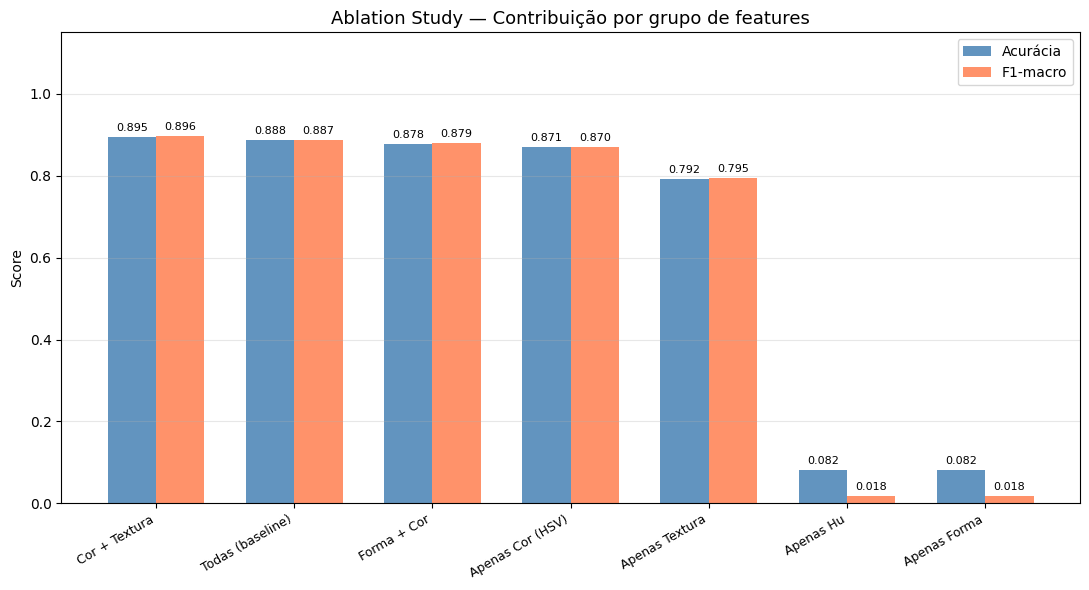

Figura salva: outputs/ablation_study.png


In [14]:
# Gráfico do ablation study
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(ablation_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], ablation_df['Acurácia'], width,
               label='Acurácia', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], ablation_df['F1-macro'], width,
               label='F1-macro', color='coral', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(ablation_df['Grupo de Features'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Ablation Study — Contribuição por grupo de features', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: outputs/ablation_study.png')

In [15]:
best_group = ablation_df.iloc[0]
print('\n=== Conclusões do Ablation Study ===')
print(f'Melhor grupo isolado: {best_group["Grupo de Features"]} (F1={best_group["F1-macro"]:.4f})')
print()
print('Interpretação:')
print('  - Features de COR capturam variações visíveis de amadurecimento e defeitos')
print('  - Features de TEXTURA complementam a discriminação em regiões com padrão similar')
print('  - Features de FORMA sozinhas tendem a ter menor poder discriminante pois os grãos')
print('    têm formas similares independentemente do defeito')
print('  - A combinação de TODOS os grupos produz o melhor resultado (sinergia)')
print()
print(f'\n✅ Notebook de bônus (XAI) concluído.')
print(f'   Arquivos salvos: shap_summary.png, permutation_importance.png, ablation_study.png/.csv')


=== Conclusões do Ablation Study ===
Melhor grupo isolado: Cor + Textura (F1=0.8964)

Interpretação:
  - Features de COR capturam variações visíveis de amadurecimento e defeitos
  - Features de TEXTURA complementam a discriminação em regiões com padrão similar
  - Features de FORMA sozinhas tendem a ter menor poder discriminante pois os grãos
    têm formas similares independentemente do defeito
  - A combinação de TODOS os grupos produz o melhor resultado (sinergia)


✅ Notebook de bônus (XAI) concluído.
   Arquivos salvos: shap_summary.png, permutation_importance.png, ablation_study.png/.csv
